In [2]:
# Instalar dependencias mínimas para ejecutar este cuaderno (ejecutar solo si faltan paquetes)
%pip install --quiet numpy pandas matplotlib scikit-learn joblib


Note: you may need to restart the kernel to use updated packages.


# Demo RAG interactivo — ai-engine
# Cuaderno: `notebooks/demo_rag.ipynb`
# Objetivo: reproducir y ampliar `examples/demo_ingest_generate.py` en celdas ejecutables.


In [9]:
## 1) Importar librerías

# Librerías estándar y científicas
import os
import sys
import json
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML / DL libs (import safely)
try:
    import torch
except Exception:
    torch = None

# Añadir ruta del proyecto (compatible con ejecución en notebook)
try:
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    cwd = Path.cwd()
    PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd

src_path = PROJECT_ROOT / "src"
print("PROJECT_ROOT:", PROJECT_ROOT)
print("src_path exists:", src_path.exists(), "->", src_path)
print("sys.path head:", sys.path[:6])
if src_path.exists():
    if str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))
else:
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))

# Importar componentes del repo (con fallbacks)
try:
    from ai_engine.config import load_config
except Exception as e:
    print("import ai_engine.config failed:", type(e), e)
    raise

try:
    from ai_engine.rag.pipeline import RAGPipeline
except Exception:
    RAGPipeline = None

try:
    from ai_engine.kbd.persistent_kb import PersistentKnowledgeBase
except Exception:
    PersistentKnowledgeBase = None

print("Python:", sys.version.splitlines()[0])
print("Numpy:", np.__version__)
print("Pandas:", pd.__version__)
print("Torch:", getattr(torch, "__version__", "not installed"))


PROJECT_ROOT: c:\Users\sebss\Documents\ai-engine
src_path exists: True -> c:\Users\sebss\Documents\ai-engine\src
sys.path head: ['c:\\Users\\sebss\\Documents\\ai-engine\\notebooks', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.13_3.13.3312.0_x64__qbz5n2kfra8p0\\python313.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.13_3.13.3312.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.13_3.13.3312.0_x64__qbz5n2kfra8p0\\Lib', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.13_3.13.3312.0_x64__qbz5n2kfra8p0', 'c:\\Users\\sebss\\Documents\\ai-engine\\.venv']
Python: 3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]
Numpy: 2.4.2
Pandas: 3.0.1
Torch: not installed


In [12]:
## 2) Configuración y constantes

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
if torch is not None:
    torch.manual_seed(SEED)

DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)

# Use load_config() but handle missing dependencies
CONFIG = {}
if 'load_config' in globals():
    try:
        CONFIG = load_config()
    except Exception as e:
        print("load_config unavailable or failed:", type(e), e)
        CONFIG = {}

MODEL_PATH = os.environ.get("MODEL_PATH") or (CONFIG.get("MODEL_PATH") if isinstance(CONFIG, dict) else None)
CHROMA_DIR = os.environ.get("CHROMA_PERSIST_DIR") or (CONFIG.get("CHROMA_PERSIST_DIR") if isinstance(CONFIG, dict) else str(DATA_DIR / "chroma"))

print("DATA_DIR:", DATA_DIR)
print("MODEL_PATH:", MODEL_PATH)
print("CHROMA_DIR:", CHROMA_DIR)


load_config unavailable or failed: <class 'RuntimeError'> PyYAML is required for configuration. Install extras 'llm' or 'pip install pyyaml'.
DATA_DIR: c:\Users\sebss\Documents\ai-engine\data
MODEL_PATH: None
CHROMA_DIR: None


In [13]:
## 3) Funciones utilitarias

def set_seed(seed:int=SEED):
    random.seed(seed)
    np.random.seed(seed)
    if torch is not None:
        torch.manual_seed(seed)

import json

def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

print("Helpers loaded.")


Helpers loaded.


In [14]:
## 4) Cargar y visualizar datos

# Demo: crear un pequeño dataset en memoria
rows = [
    {"id": 1, "title": "DemoGame", "text": "This is a demo game about space exploration."},
    {"id": 2, "title": "DemoQuiz", "text": "Short quiz content on history and geography."}
]

df = pd.DataFrame(rows)

df.head()


,id,title,text
0,1,DemoGame,This is a demo game about space exploration.
1,2,DemoQuiz,Short quiz content on history and geography.


In [15]:
## 5) Preprocesamiento

def simple_clean(text: str) -> str:
    return text.strip()

# Aplicar al dataset
if not df.empty:
    df['clean_text'] = df['text'].apply(simple_clean)
    display(df[['id','title','clean_text']])


,id,title,clean_text
0,1,DemoGame,This is a demo game about space exploration.
1,2,DemoQuiz,Short quiz content on history and geography.


In [16]:
## 6) Implementación del "modelo" / RAG pipeline

# Para este cuaderno usaremos dos demostraciones:
#  A) Un clasificador scikit-learn sencillo como placeholder
#  B) La integración RAG si los componentes del proyecto están disponibles

# A) ejemplo rápido sklearn (placeholder)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

X = df['clean_text'].astype(str)
y = [0 if r['id']==1 else 1 for r in rows]

sk_model = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=200))
sk_model.fit(X, y)
print("Sklearn model trained on demo data.")

# B) RAG pipeline (si está disponible)
if RAGPipeline is not None:
    print("RAGPipeline available:", RAGPipeline)
else:
    print("RAGPipeline not available in this environment; use the sklearn placeholder.")


Sklearn model trained on demo data.
RAGPipeline available: <class 'ai_engine.rag.pipeline.RAGPipeline'>


In [18]:
## 7) Entrenamiento y ajuste de hiperparámetros

# En este demo el "entrenamiento" ya se hizo (sklearn fit). Para mostrar un ejemplo de búsqueda de hiperparámetros:
from sklearn.model_selection import GridSearchCV

param_grid = { 'logisticregression__C': [0.1, 1.0, 10.0] }
search = GridSearchCV(sk_model, param_grid, cv=2)
try:
    search.fit(X, y)
    print("Best params:", search.best_params_)
except Exception as e:
    print("GridSearch failed or not enough samples for CV, using fitted model as fallback:", type(e), e)
    search = sk_model
    # Provide a default best_params_ for downstream code compatibility
    try:
        search.best_params_ = {'logisticregression__C': 1.0}
    except Exception:
        pass


GridSearch failed or not enough samples for CV, using fitted model as fallback: <class 'ValueError'> n_splits=2 cannot be greater than the number of members in each class.


In [19]:
## 8) Evaluación y métricas

from sklearn.metrics import accuracy_score, classification_report

preds = search.predict(X)
print("Accuracy:", accuracy_score(y, preds))
print(classification_report(y, preds))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



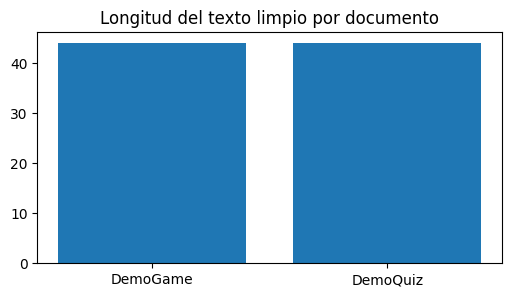

In [20]:
## 9) Visualizaciones

plt.figure(figsize=(6,3))
plt.bar(df['title'], [len(x) for x in df['clean_text']])
plt.title('Longitud del texto limpio por documento')
plt.show()


In [22]:
## 10) Guardar y cargar artefactos

# Guardar un modelo sklearn como ejemplo
import joblib
MODEL_FILE = DATA_DIR / "sk_model.joblib"

# search may be a GridSearchCV or a pipeline fallback; handle both cases
estimator = getattr(search, 'best_estimator_', None) or search
joblib.dump(estimator, MODEL_FILE)
print("Saved sklearn model to:", MODEL_FILE)

# Cargar y predecir
loaded = joblib.load(MODEL_FILE)
print("Loaded model predicts:", loaded.predict(X))


Saved sklearn model to: c:\Users\sebss\Documents\ai-engine\data\sk_model.joblib
Loaded model predicts: [0 1]


In [23]:
## 11) Pruebas unitarias (ejemplos)

# Pequeñas pruebas rápidas ejecutables dentro del cuaderno

def test_simple_clean():
    assert simple_clean(" x ") == "x"

print("Running quick unit tests...")
try:
    test_simple_clean()
    print("test_simple_clean passed")
except AssertionError:
    print("test_simple_clean FAILED")


Running quick unit tests...
test_simple_clean passed


## 12) Ejecución e integración con VSCode

- Para ejecutar celdas en VSCode: abrir el cuaderno y usar los botones de ejecución por celda o `Run All`.
- Para ejecutar desde terminal: `jupyter nbconvert --to notebook --execute notebooks/demo_rag.ipynb`
- Outputs se guardan en `data/` y modelos en `data/`.

# Fin del cuaderno — editar según necesidad para incluir `RAGPipeline` y `LlamaClient` cuando estén disponibles.
